In [1]:
import numpy as np
from PIL import Image, ImageDraw, ImageFont
import os
import string
import matplotlib.pyplot as plt
#creating a 35 classes
CLASSES = list(string.ascii_uppercase)+[str(i) for i in range(1,10)]
print(f"Total classes: {len(CLASSES)}")
print(CLASSES)

Total classes: 35
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [2]:
import glob
#checking if the fornts are present in the system
if os.name == 'nt':
    font_dir = "C:/Windows/Fonts/"
    font_file = ["arial.ttf", "times.ttf", "cour.ttf", "verdana.ttf"]
else: 
    font_dir = "/System/Library/Fonts/" if os.path.exists("/System/Library/Fonts/") else "/usr/share/fonts/truetype/dejavu/"
    font_file = ["Arial.ttf", "Times.ttc", "Courier.ttc", "DejaVuSans.ttf"]
FONT_PATHS = [font_dir + f for f in font_file if os.path.exists(font_dir + f)]
print("Found fonts:", FONT_PATHS)
if len(FONT_PATHS) == 0:
    print("No fonts found")

Found fonts: ['C:/Windows/Fonts/arial.ttf', 'C:/Windows/Fonts/times.ttf', 'C:/Windows/Fonts/cour.ttf', 'C:/Windows/Fonts/verdana.ttf']


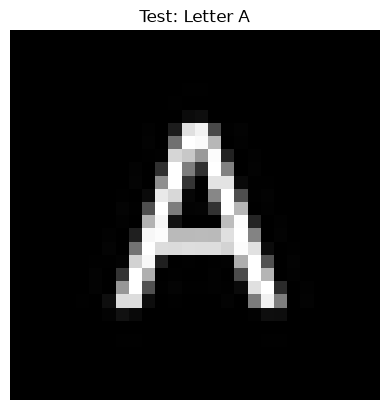

In [3]:
IMG_SIZE = 28 
#this function helps to generate a single rendered image
def img_generation(char, font_path, img_size=IMG_SIZE, rotation=0, noise_level=0):
    render_size = 64
    img = Image.new('L', (render_size, render_size), color=0)  
    draw = ImageDraw.Draw(img)
    font = ImageFont.truetype(font_path, size=44)
    
    bbox = draw.textbbox((0, 0), char, font=font)
    w, h = bbox[2] - bbox[0], bbox[3] - bbox[1]
    x = (render_size - w) / 2 - bbox[0]
    y = (render_size - h) / 2 - bbox[1]
    
    draw.text((x, y), char, fill=255, font=font)
    
    if rotation != 0:
        img = img.rotate(rotation, fillcolor=0)
    
    img = img.resize((img_size, img_size), Image.LANCZOS)
    
    arr = np.array(img, dtype=np.float32) / 255.0

    if noise_level > 0:
        noise = np.random.normal(0, noise_level, arr.shape)
        arr = np.clip(arr + noise, 0, 1)
    
    return arr

test_img = img_generation('A', FONT_PATHS[0])
plt.imshow(test_img, cmap='gray')
plt.title("Test: Letter A")
plt.axis('off')
plt.show()

In [4]:
sample_per_class = 60  

#this function helps to create a complete dataset for the model

def full_dataset():
    X_list = []
    y_list = []
    for class_idx, char in enumerate(CLASSES):
        for i in range(sample_per_class):
            font_path = np.random.choice(FONT_PATHS)
            rotation = np.random.uniform(-15, 15)   
            noise_level = np.random.uniform(0, 0.05)  
            
            img = img_generation(char, font_path, rotation=rotation, noise_level=noise_level)
            X_list.append(img)
            y_list.append(class_idx)
        
        if class_idx % 5 == 0:
            print(f"Generated class {class_idx+1}/{len(CLASSES)}: '{char}'")
    
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.int64)
    
    return X, y

X, y = full_dataset()
print(f"\nDataset shape: X={X.shape}, y={y.shape}")
print(f"Samples per class: {sample_per_class}, Total classes: {len(CLASSES)}, Total samples: {len(X)}")

Generated class 1/35: 'A'
Generated class 6/35: 'F'
Generated class 11/35: 'K'
Generated class 16/35: 'P'
Generated class 21/35: 'U'
Generated class 26/35: 'Z'
Generated class 31/35: '5'

Dataset shape: X=(2100, 28, 28), y=(2100,)
Samples per class: 60, Total classes: 35, Total samples: 2100


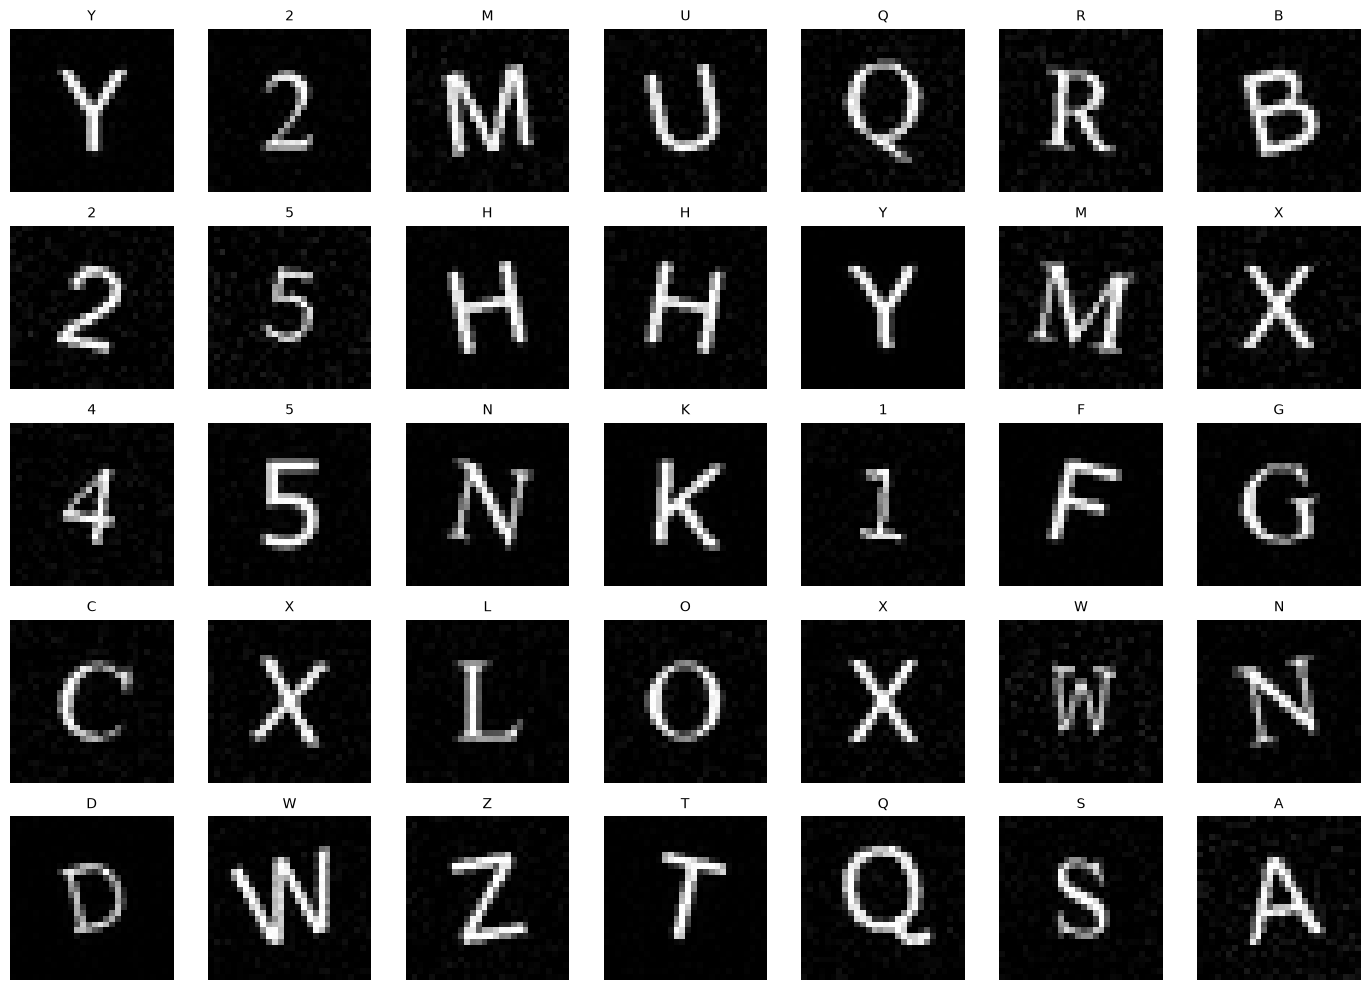

In [5]:
#This cell is used to visualizes the random data

fig, axes = plt.subplots(5, 7, figsize=(14, 10))
random_indices = np.random.choice(len(X), 35, replace=False)

for ax, idx in zip(axes.flat, random_indices):
    ax.imshow(X[idx], cmap='gray')
    ax.set_title(CLASSES[y[idx]], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [6]:
from sklearn.model_selection import train_test_split

#this function is used to split the data for training and testing

def one_hot_encode(y, num_classes):

    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

X_flat = X.reshape(X.shape[0], -1)
print(f"Flattened shape: {X_flat.shape}")

NUM_CLASSES = len(CLASSES)
y_onehot = one_hot_encode(y, NUM_CLASSES)
print(f"One-hot labels shape: {y_onehot.shape}")

X_train, X_temp, y_train, y_temp = train_test_split(X_flat, y_onehot, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=np.argmax(y_temp, axis=1))

print(f"\nTrain: {X_train.shape}, {y_train.shape}")
print(f"Val:   {X_val.shape}, {y_val.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

Flattened shape: (2100, 784)
One-hot labels shape: (2100, 35)

Train: (1470, 784), (1470, 35)
Val:   (315, 784), (315, 35)
Test:  (315, 784), (315, 35)


In [7]:
#save the datas into harddrive
os.makedirs('data', exist_ok=True)
np.savez('data/character_dataset.npz',
          X_train=X_train, y_train=y_train,
          X_val=X_val, y_val=y_val,
          X_test=X_test, y_test=y_test,
          classes=CLASSES)
print("Dataset saved to data/character_dataset.npz")

Dataset saved to data/character_dataset.npz


In [8]:
class NeuralNetwork:
    #starting step of neural network skeleton
    def __init__(self, layer_sizes, activation='relu', seed=42):
        np.random.seed(seed)
        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes) - 1  
        self.activation_type = activation
        self.weights = []
        self.biases = []
        for i in range(self.num_layers):
            fan_in = layer_sizes[i]
            fan_out = layer_sizes[i + 1]
            limit = np.sqrt(2.0 / fan_in)
            W = np.random.randn(fan_in, fan_out) * limit
            b = np.zeros((1, fan_out))
            self.weights.append(W)
            self.biases.append(b)
        self.z_cache = [] 
        self.a_cache = [] 

    #applies a element wise activation function to the hidden layer
    def activation(self, z):
        if self.activation_type == 'relu':
            return np.maximum(0, z)
        elif self.activation_type == 'tanh':
            return np.tanh(z)
        else:
            raise ValueError("Error")

    #This function is useful while BP because it computes the derivative of the selected activation function with respect to z
    def activation_derivative(self, z):
        if self.activation_type == 'relu':
            return (z > 0).astype(float)
        elif self.activation_type == 'tanh':
            return 1 - np.tanh(z) ** 2

    #applies the softmax AF to last layer
    def softmax(self, z):
        z_shifted = z - np.max(z, axis=1, keepdims=True) 
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    #execue the forward pass
    def forward(self, X):    
        self.z_cache = []
        self.a_cache = [X]  
        
        a = X
        for i in range(self.num_layers):
            z = a @ self.weights[i] + self.biases[i]
            self.z_cache.append(z)
            
            if i < self.num_layers - 1:
                a = self.activation(z)
            else:
                a = self.softmax(z)
            
            self.a_cache.append(a)
        
        return a

net = NeuralNetwork(layer_sizes=[784, 128, 64, 35], activation='relu')
sample_output = net.forward(X_train[:5])
print(f"Output shape: {sample_output.shape}")
print(f"Row sums (should be ~1.0 each, since softmax): {sample_output.sum(axis=1)}")

Output shape: (5, 35)
Row sums (should be ~1.0 each, since softmax): [1. 1. 1. 1. 1.]


In [9]:
#this function is used to find the amount loss in prediction 
def cross_entropy_loss(y_pred, y_true):
    epsilon = 1e-12 
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
    batch_size = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred_clipped)) / batch_size
    return loss

#used to find the Accuracy 
def accuracy(y_pred, y_true):
    pred_labels = np.argmax(y_pred, axis=1)
    true_labels = np.argmax(y_true, axis=1)
    return np.mean(pred_labels == true_labels)

In [10]:
class NeuralNetwork: #rebuilded
    def __init__(self, layer_sizes, activation='relu', seed=42):
        np.random.seed(seed)
        self.layer_sizes = layer_sizes
        self.num_layers = len(layer_sizes) - 1
        self.activation_type = activation
        self.weights = []
        self.biases = []
        for i in range(self.num_layers):
            fan_in = layer_sizes[i]
            fan_out = layer_sizes[i + 1]
            limit = np.sqrt(2.0 / fan_in)
            W = np.random.randn(fan_in, fan_out) * limit
            b = np.zeros((1, fan_out))
            self.weights.append(W)
            self.biases.append(b)
        self.z_cache = []
        self.a_cache = []
    def _activation(self, z):
        if self.activation_type == 'relu':
            return np.maximum(0, z)
        elif self.activation_type == 'tanh':
            return np.tanh(z)
    def _activation_derivative(self, z):
        if self.activation_type == 'relu':
            return (z > 0).astype(float)
        elif self.activation_type == 'tanh':
            return 1 - np.tanh(z) ** 2
    def _softmax(self, z):
        z_shifted = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z_shifted)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)
    def forward(self, X):
        self.z_cache = []
        self.a_cache = [X]
        a = X
        for i in range(self.num_layers):
            z = a @ self.weights[i] + self.biases[i]
            self.z_cache.append(z)
            if i < self.num_layers - 1:
                a = self._activation(z)
            else:
                a = self._softmax(z)
            self.a_cache.append(a)
        return a

    #backward propagation
    def backward(self, y_true, learning_rate=0.01):
        batch_size = y_true.shape[0]
        dz = self.a_cache[-1] - y_true      
        for i in reversed(range(self.num_layers)):
            a_prev = self.a_cache[i]  
            dW = (a_prev.T @ dz) / batch_size
            db = np.sum(dz, axis=0, keepdims=True) / batch_size
            if i > 0:
                da_prev = dz @ self.weights[i].T
                dz = da_prev * self._activation_derivative(self.z_cache[i - 1])
            self.weights[i] -= learning_rate * dW
            self.biases[i] -= learning_rate * db
net = NeuralNetwork(layer_sizes=[784, 128, 64, 35], activation='relu')
print("Rebuilt")

Rebuilt


In [11]:
#this the model training function

def train(net, X_train, y_train, X_val, y_val, epochs=100, batch_size=32, learning_rate=0.01):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    n_samples = X_train.shape[0]
    for epoch in range(epochs):
        perm = np.random.permutation(n_samples)
        X_shuffled = X_train[perm]
        y_shuffled = y_train[perm]
        for start in range(0, n_samples, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            net.forward(X_batch)          
            net.backward(y_batch, learning_rate) 
        train_pred = net.forward(X_train)
        train_loss = cross_entropy_loss(train_pred, y_train)
        train_acc = accuracy(train_pred, y_train)
        val_pred = net.forward(X_val)
        val_loss = cross_entropy_loss(val_pred, y_val)
        val_acc = accuracy(val_pred, y_val)
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"Epoch {epoch:3d} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    return history

net = NeuralNetwork(layer_sizes=[784, 128, 64, 35], activation='relu', seed=42)
history = train(net, X_train, y_train, X_val, y_val, epochs=100, batch_size=32, learning_rate=0.1)

Epoch   0 | Train Loss: 2.1796 Acc: 0.5503 | Val Loss: 2.2023 Acc: 0.5238
Epoch  10 | Train Loss: 0.0419 Acc: 0.9993 | Val Loss: 0.0731 Acc: 0.9905
Epoch  20 | Train Loss: 0.0153 Acc: 1.0000 | Val Loss: 0.0416 Acc: 0.9937
Epoch  30 | Train Loss: 0.0082 Acc: 1.0000 | Val Loss: 0.0324 Acc: 0.9968
Epoch  40 | Train Loss: 0.0054 Acc: 1.0000 | Val Loss: 0.0277 Acc: 0.9968
Epoch  50 | Train Loss: 0.0040 Acc: 1.0000 | Val Loss: 0.0255 Acc: 0.9968
Epoch  60 | Train Loss: 0.0031 Acc: 1.0000 | Val Loss: 0.0249 Acc: 0.9968
Epoch  70 | Train Loss: 0.0026 Acc: 1.0000 | Val Loss: 0.0242 Acc: 0.9968
Epoch  80 | Train Loss: 0.0022 Acc: 1.0000 | Val Loss: 0.0245 Acc: 0.9968
Epoch  90 | Train Loss: 0.0019 Acc: 1.0000 | Val Loss: 0.0239 Acc: 0.9968
Epoch  99 | Train Loss: 0.0016 Acc: 1.0000 | Val Loss: 0.0234 Acc: 0.9968


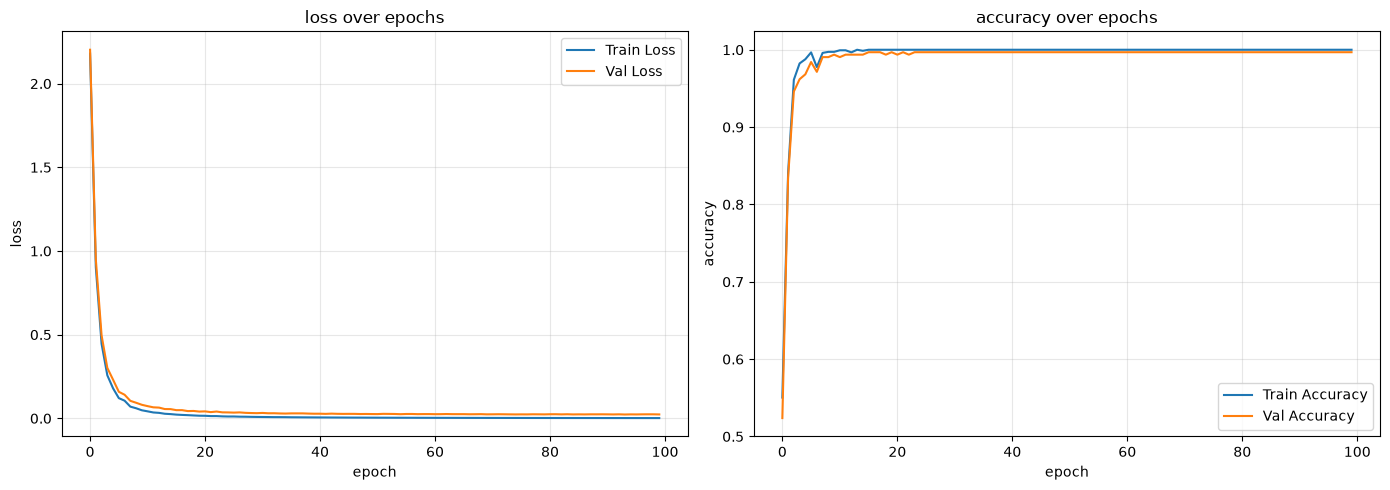

In [12]:
#this cell create a chart for the training progress

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].set_title('loss over epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].plot(history['train_acc'], label='Train Accuracy')
axes[1].plot(history['val_acc'], label='Val Accuracy')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_title('accuracy over epochs')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [13]:
#the exam phase of the model where it is tested with the remaining data

test_pred = net.forward(X_test)
test_loss = cross_entropy_loss(test_pred, y_test)
test_acc = accuracy(test_pred, y_test)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Loss: 0.0178
Final Test Accuracy: 0.9937


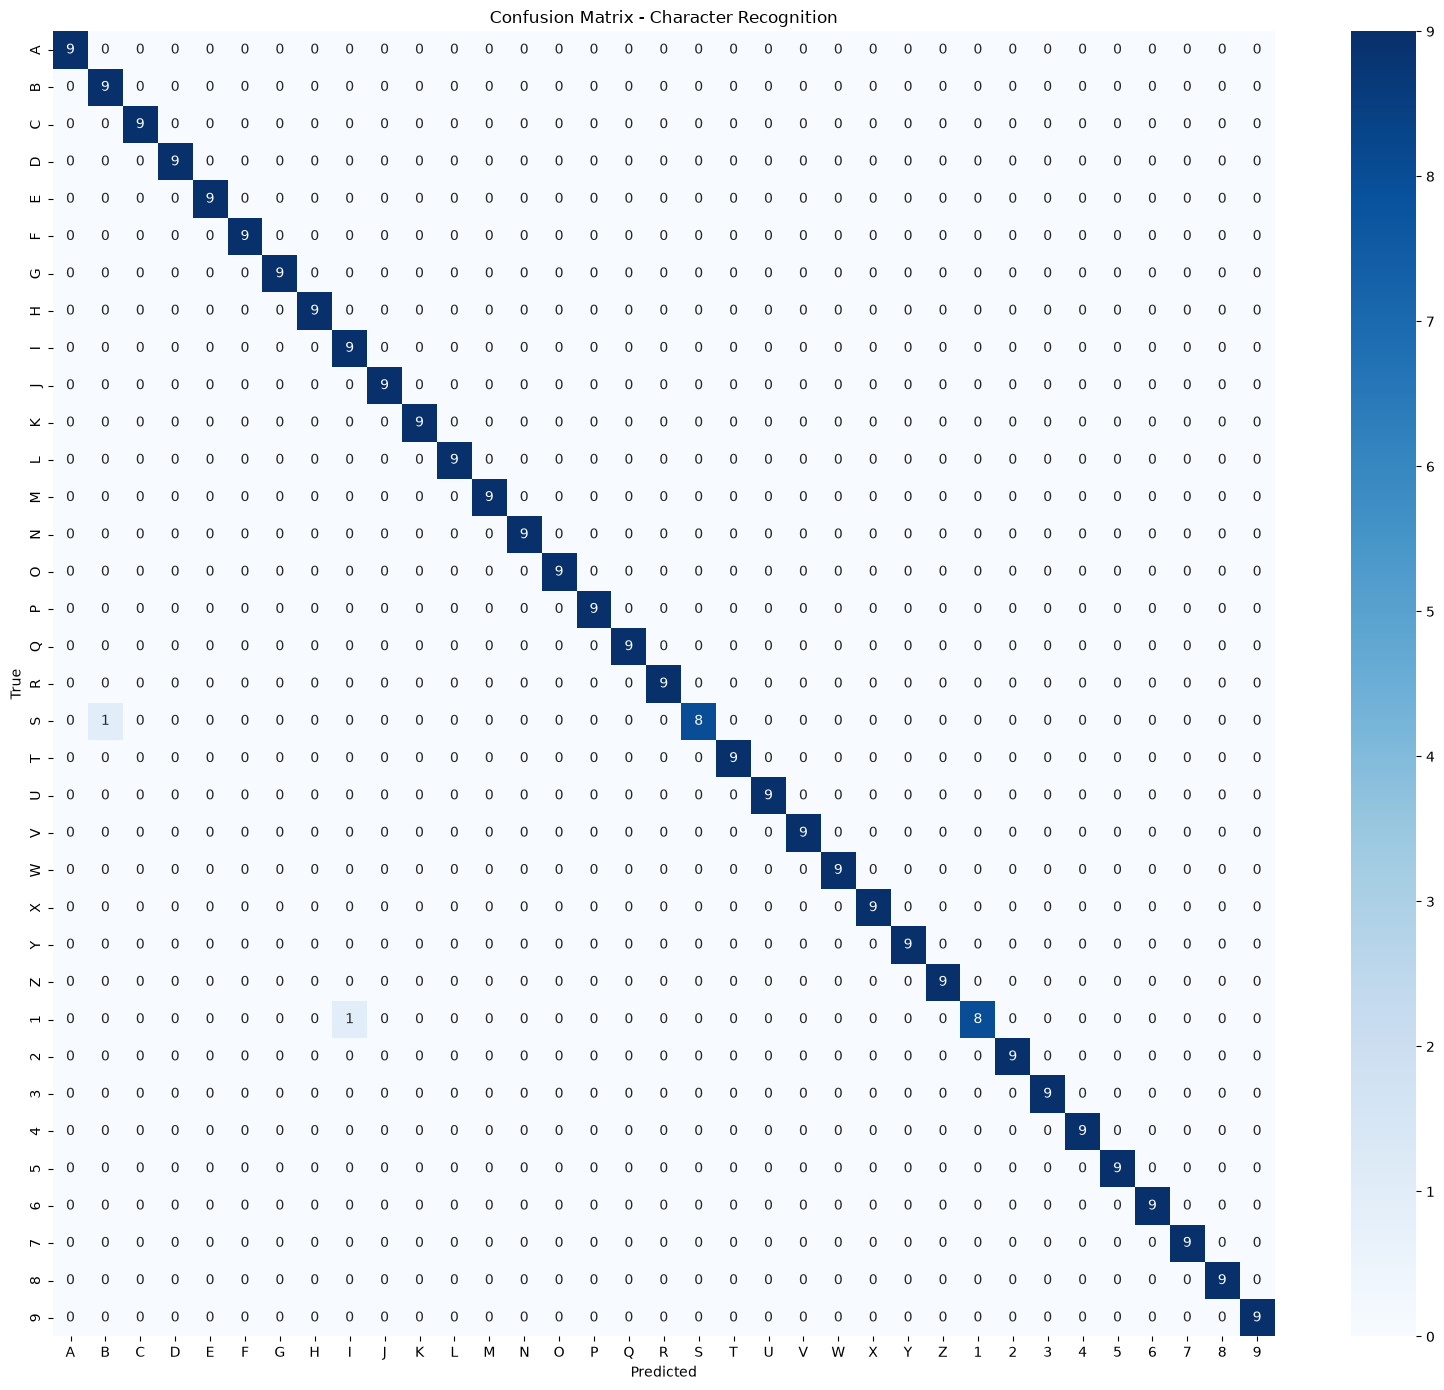

              precision    recall  f1-score   support

           A       1.00      1.00      1.00         9
           B       0.90      1.00      0.95         9
           C       1.00      1.00      1.00         9
           D       1.00      1.00      1.00         9
           E       1.00      1.00      1.00         9
           F       1.00      1.00      1.00         9
           G       1.00      1.00      1.00         9
           H       1.00      1.00      1.00         9
           I       0.90      1.00      0.95         9
           J       1.00      1.00      1.00         9
           K       1.00      1.00      1.00         9
           L       1.00      1.00      1.00         9
           M       1.00      1.00      1.00         9
           N       1.00      1.00      1.00         9
           O       1.00      1.00      1.00         9
           P       1.00      1.00      1.00         9
           Q       1.00      1.00      1.00         9
           R       1.00    

In [14]:
#used to print the confusion matrix

import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
test_pred_labels = np.argmax(test_pred, axis=1)
test_true_labels = np.argmax(y_test, axis=1)
cm = confusion_matrix(test_true_labels, test_pred_labels)
plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',xticklabels=CLASSES, yticklabels=CLASSES, cbar=True)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Character Recognition')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(test_true_labels, test_pred_labels, target_names=CLASSES))

In [15]:
#we are rotating and increasing the noice of the feature

def test_set(n_per_class=10):
    X_list = []
    y_list = []
    for class_idx, char in enumerate(CLASSES):
        for i in range(n_per_class):
            font_path = np.random.choice(FONT_PATHS)
            rotation = np.random.uniform(-35, 35)     
            noise_level = np.random.uniform(0.1, 0.25) 
            img = img_generation(char, font_path, rotation=rotation, noise_level=noise_level)
            X_list.append(img.flatten())
            y_list.append(class_idx)
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int64)
X_hard, y_hard = test_set(n_per_class=10)
y_hard_onehot = one_hot_encode(y_hard, NUM_CLASSES)
hard_pred = net.forward(X_hard)
hard_pred_labels = np.argmax(hard_pred, axis=1)
hard_acc = accuracy(hard_pred, y_hard_onehot)
print(f"Hard test set accuracy: {hard_acc:.4f}")
print(f"Misclassified: {np.sum(hard_pred_labels != y_hard)} out of {len(y_hard)}")

Hard test set accuracy: 0.7000
Misclassified: 105 out of 350


Total misclassified in hard set: 105


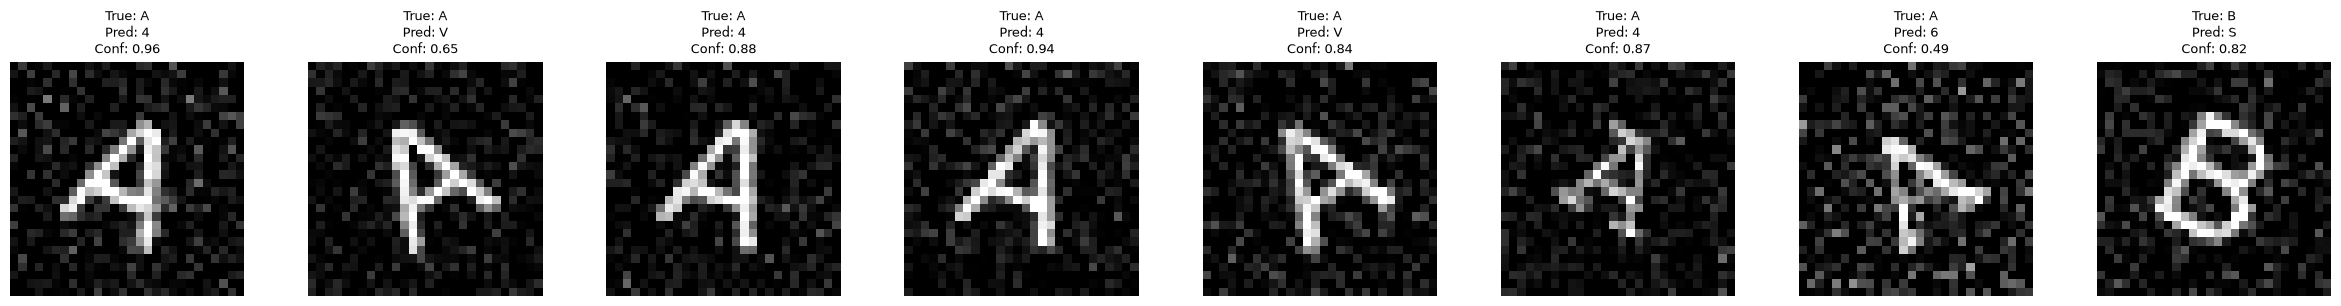

In [16]:
#used to show the missclassified data

misclassified_idx = np.where(hard_pred_labels != y_hard)[0]
print(f"Total misclassified in hard set: {len(misclassified_idx)}")
n_show = min(8, len(misclassified_idx))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(3*n_show, 3))
    if n_show == 1:
        axes = [axes]    
    for ax, idx in zip(axes, misclassified_idx[:n_show]):
        img = X_hard[idx].reshape(28, 28)
        true_label = CLASSES[y_hard[idx]]
        pred_label = CLASSES[hard_pred_labels[idx]]
        confidence = hard_pred[idx][hard_pred_labels[idx]]
        ax.imshow(img, cmap='gray')
        ax.set_title(f"True: {true_label}\nPred: {pred_label}\nConf: {confidence:.2f}", fontsize=9)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('hard_misclassified_examples.png', dpi=150)
    plt.show()
else:
    print("no misclassifications")

In [17]:
#model performance on rotated and noisy image 

for i, idx in enumerate(misclassified_idx[:8]):
    true_label = CLASSES[y_hard[idx]]
    pred_label = CLASSES[hard_pred_labels[idx]]
    confidence = hard_pred[idx][hard_pred_labels[idx]]
    true_confidence = hard_pred[idx][y_hard[idx]]    
    print(f"Example {i+1}:")
    print(f"  True label: {true_label} | Predicted: {pred_label}")
    print(f"  Confidence in wrong prediction: {confidence:.2%}")
    print(f"  Model's confidence in correct label: {true_confidence:.2%}")
    print()
from collections import Counter
confusion_pairs = Counter()
for idx in misclassified_idx:
    true_c = CLASSES[y_hard[idx]]
    pred_c = CLASSES[hard_pred_labels[idx]]
    confusion_pairs[(true_c, pred_c)] += 1
print("Most common confusion pairs:")
for (true_c, pred_c), count in confusion_pairs.most_common(10):
    print(f"  {true_c} -> {pred_c}: {count} times")

Example 1:
  True label: A | Predicted: 4
  Confidence in wrong prediction: 96.06%
  Model's confidence in correct label: 1.46%

Example 2:
  True label: A | Predicted: V
  Confidence in wrong prediction: 65.01%
  Model's confidence in correct label: 16.76%

Example 3:
  True label: A | Predicted: 4
  Confidence in wrong prediction: 87.82%
  Model's confidence in correct label: 11.60%

Example 4:
  True label: A | Predicted: 4
  Confidence in wrong prediction: 93.64%
  Model's confidence in correct label: 4.97%

Example 5:
  True label: A | Predicted: V
  Confidence in wrong prediction: 84.47%
  Model's confidence in correct label: 2.01%

Example 6:
  True label: A | Predicted: 4
  Confidence in wrong prediction: 86.82%
  Model's confidence in correct label: 0.39%

Example 7:
  True label: A | Predicted: 6
  Confidence in wrong prediction: 49.29%
  Model's confidence in correct label: 4.18%

Example 8:
  True label: B | Predicted: S
  Confidence in wrong prediction: 81.89%
  Model's co